# Feature Engineering of Market Risk Variables

This notebook is the second step of the empirical pipeline developed for the TFM.

Its objective is to construct a set of market-based financial features from the IBEX 35 dataset generated in Notebook 1. These variables are designed to characterize the behaviour of the market in terms of performance, volatility, downside risk, extreme risk, cumulative deterioration and distributional shape.

The notebook performs six main tasks:

1. Load the cleaned dataset generated in Notebook 1
2. Construct rolling performance and risk features
3. Assemble the master dataset for Chapter 2
4. Define the train/test split schemes
5. Produce descriptive tables and figures for Chapter 2
6. Export datasets, tables and figures for later analysis

The final outputs of this notebook are:

- `data/processed/dataset_cap2_master.csv`
- `data/processed/dataset_cap3_input.csv`
- `tables/dataset_summary.csv`
- `tables/descriptive_statistics.csv`
- `tables/correlation_matrix.csv`
- `figures/chapter2/*`

## Notebook overview

This notebook takes as input the file generated in Notebook 1:

`data/raw/ibex_prices.csv`

and transforms it into the empirical dataset used in Chapter 2 of the TFM.

The resulting variables are intended to capture:

- market return dynamics
- volatility
- downside risk
- tail risk
- cumulative market deterioration
- distributional asymmetry

## 1. Environment setup

We begin by importing the required libraries and defining the technical and methodological parameters of the notebook.

All paths are defined using relative references in order to keep the pipeline reproducible and portable across machines.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.6f}".format)

# Matplotlib config (consistente para figuras del TFM)
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

## 2. Project paths

The notebook uses relative paths anchored at the repository root.

The raw dataset generated in Notebook 1 is loaded from `data/raw/`, while the outputs of this notebook are exported to `data/processed/`, `tables/` and `figures/chapter2/`.

In [2]:
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter2"

# Create directories if they don't exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Check raw data exists (importante para reproducibilidad)
raw_file = RAW_DATA_DIR / "ibex_prices.csv"
if not raw_file.exists():
    raise FileNotFoundError(f"Missing input file: {raw_file}")

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Tables directory:", TABLES_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio
Raw data directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/raw
Processed data directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed
Tables directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables
Figures directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter2


## 3. Methodological parameters

This section centralizes the empirical choices used throughout the notebook.

The feature set is intentionally compact and organized around two rolling horizons:

- 20 trading days, representing short-term market dynamics
- 60 trading days, representing medium-term market dynamics

Extreme risk is estimated using historical VaR and CVaR at the 95% confidence level over a 60-day rolling window.

In [3]:
INPUT_FILE = RAW_DATA_DIR / "ibex_prices.csv"

# Rolling windows
SHORT_WINDOW = 20
MEDIUM_WINDOW = 60

# Tail risk parameters
VAR_CONFIDENCE = 0.95
VAR_TAIL_PROB = 1 - VAR_CONFIDENCE

# Sample splits (aligned with Chapter 2)
MAIN_TEST_START = pd.Timestamp("2021-01-01")
ROBUST_TEST_START = pd.Timestamp("2020-01-01")

## 4. Load base dataset

We now load the cleaned dataset generated in Notebook 1, the starting point of the feature engineering process.

In [4]:
## 4. Load base dataset

# Load dataset
df = pd.read_csv(INPUT_FILE, parse_dates=["date"])

# Basic validation
required_cols = ["date", "ibex_close", "ret_1d"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Sort and set time index (clave para rolling)
df = df.sort_values("date").reset_index(drop=True)
df = df.set_index("date")

print("Dataset loaded correctly")
print(df.shape)
df.head()

Dataset loaded correctly
(6164, 2)


,ibex_close,ret_1d
date,,
2002-01-03,"8,554.691406",0.020979
2002-01-04,"8,463.090820",-0.010765
2002-01-07,"8,177.291504",-0.034353
2002-01-08,"8,186.591797",0.001137
2002-01-09,"8,066.091797",-0.014829


## 5. Initial validation of the base dataset

Before constructing additional variables, we verify that the input dataset has the expected structure and no contains data integrity issues.

In [5]:
## 5. Initial validation of the base dataset

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Date range:", df.index.min(), "to", df.index.max())
print("Missing values:\n", df.isna().sum())
print("Duplicate dates:", df.index.duplicated().sum())
print("Chronologically sorted:", df.index.is_monotonic_increasing)

# Assertions
assert df.index.is_monotonic_increasing, "Dates are not ordered"
assert df.index.duplicated().sum() == 0, "Duplicate dates found"

Shape: (6164, 2)
Columns: ['ibex_close', 'ret_1d']
Date range: 2002-01-03 00:00:00 to 2026-03-13 00:00:00
Missing values:
 ibex_close    0
ret_1d        0
dtype: int64
Duplicate dates: 0
Chronologically sorted: True


## 6. Construction of market features

The feature set is organized into six conceptual blocks:

1. performance features
2. volatility features
3. downside risk features
4. tail risk features
5. cumulative deterioration
6. distributional shape

These features are intended to characterize the state of the market at each point in time using only information available up to that date. Together, they provide the empirical basis for the descriptive analysis developed in Chapter 2.

### 6.1 Performance features

For log returns, the correct cumulative return over a rolling window is the sum of the log returns in that window. This follows from the additive property of log returns over time.

Therefore:

- `ret_20d` is computed as the rolling sum of daily log returns over 20 trading days
- `ret_60d` is computed as the rolling sum of daily log returns over 60 trading days

In [6]:
df["ret_20d"] = df["ret_1d"].rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).sum()
df["ret_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).sum()

### 6.2 Volatility features

Volatility is computed over 20 and 60 trading days in order to capture both short-term and medium-term fluctuations in market risk.

At this stage, volatility is kept in its rolling standard deviation form rather than annualized, as the objective is to construct internally consistent features for the empirical characterization of market risk dynamics. This choice ensures comparability across variables and avoids introducing additional scaling that is not required for the descriptive analysis developed in Chapter 2.

In [7]:
df["vol_20d"] = df["ret_1d"].rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).std(ddof=1)
df["vol_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).std(ddof=1)

### 6.3 Downside risk features

Downside risk aims to isolate the variability associated with negative returns only.

In this notebook, downside volatility is computed using only the subset of returns that are strictly negative within each rolling window. This approach is consistent with the economic interpretation of risk as exposure to losses, and differs from alternative definitions based on semivariance, where non-negative returns are set to zero.

This is especially relevant in a TFM focused on extreme risk and CVaR, since standard volatility treats positive and negative deviations symmetrically, whereas downside risk focuses on harmful market movements.

In [8]:
def downside_volatility(series):
    negative_returns = series[series < 0]
    if len(negative_returns) == 0:
        return np.nan
    return negative_returns.std(ddof=1)

df["downside_vol_20d"] = df["ret_1d"].rolling(window=SHORT_WINDOW).apply(
    downside_volatility, raw=False
)

df["downside_vol_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW).apply(
    downside_volatility, raw=False
)

### 6.4 Tail risk features

Extreme market risk is captured using historical (non-parametric) Value at Risk (VaR) and Conditional Value at Risk (CVaR) at the 95% confidence level over a 60-day rolling window.

Both measures are computed directly from the empirical distribution of returns within each window, without imposing parametric assumptions. Given that the analysis is based on returns, extreme risk corresponds to the left tail of the distribution, associated with large negative returns.

In [9]:
def historical_var(series, alpha=VAR_TAIL_PROB):
    return np.quantile(series, alpha)

def historical_cvar(series, alpha=VAR_TAIL_PROB):
    var_threshold = np.quantile(series, alpha)
    tail_losses = series[series <= var_threshold]
    return tail_losses.mean() if len(tail_losses) > 0 else np.nan

df["var_95_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).apply(
    lambda x: historical_var(x), raw=True
)

df["cvar_95_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).apply(
    lambda x: historical_cvar(x), raw=True
)

### 6.5 Drawdown and cumulative market deterioration

Drawdown measures the percentage decline of the index relative to its running historical maximum.

It is a particularly useful variable because it captures persistent market deterioration, not just isolated daily shocks. In this sense, it introduces a notion of memory into the analysis, allowing us to distinguish between temporary volatility spikes and sustained periods of market weakness.

In [10]:
running_max = df["ibex_close"].cummax()
df["drawdown"] = df["ibex_close"] / running_max - 1.0

### 6.6 Distributional shape

As a complementary feature, we compute rolling skewness over 60 trading days.

This variable is not intended to be a central feature in the same sense as volatility or CVaR, but it provides additional information about the asymmetry of the return distribution. In particular, it helps identify periods in which negative tail events become more likely, which is consistent with the focus on downside and extreme risk in this analysis.

In [11]:
df["skew_60d"] = df["ret_1d"].rolling(
    window=MEDIUM_WINDOW,
    min_periods=MEDIUM_WINDOW
).skew()

## 7. Master dataset assembly

Once all features have been constructed, they are assembled into a single master dataset.

The initial rows affected by rolling window computations are removed so that the final dataset only contains observations with fully available information across all variables.

In [14]:
feature_columns = [
    "ibex_close",
    "ret_1d",
    "ret_20d",
    "ret_60d",
    "vol_20d",
    "vol_60d",
    "downside_vol_20d",
    "downside_vol_60d",
    "var_95_60d",
    "cvar_95_60d",
    "drawdown",
    "skew_60d",
]

master_df = df[feature_columns].copy()
master_df = master_df.dropna(subset=feature_columns)
master_df = master_df.reset_index()   # recupera date como columna
master_df = master_df.sort_values("date").reset_index(drop=True)

## 8. Validation of the master dataset

Before moving to the sample split and descriptive analysis, we verify that the feature engineering process has produced a clean and internally consistent dataset.

In [15]:
print("Master dataset shape:", master_df.shape)
print("Date range:", master_df["date"].min(), "to", master_df["date"].max())
print("Missing values:\n", master_df.isna().sum())
print("Columns:", list(master_df.columns))
print(master_df.dtypes)

Master dataset shape: (6105, 13)
Date range: 2002-03-27 00:00:00 to 2026-03-13 00:00:00
Missing values:
 date                0
ibex_close          0
ret_1d              0
ret_20d             0
ret_60d             0
vol_20d             0
vol_60d             0
downside_vol_20d    0
downside_vol_60d    0
var_95_60d          0
cvar_95_60d         0
drawdown            0
skew_60d            0
dtype: int64
Columns: ['date', 'ibex_close', 'ret_1d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'downside_vol_20d', 'downside_vol_60d', 'var_95_60d', 'cvar_95_60d', 'drawdown', 'skew_60d']
date                datetime64[us]
ibex_close                 float64
ret_1d                     float64
ret_20d                    float64
ret_60d                    float64
vol_20d                    float64
vol_60d                    float64
downside_vol_20d           float64
downside_vol_60d           float64
var_95_60d                 float64
cvar_95_60d                float64
drawdown                   float

In [16]:
assert master_df["date"].is_monotonic_increasing, "Dates are not ordered"

assert (master_df["downside_vol_20d"] >= 0).all(), "Negative downside_vol_20d found"
assert (master_df["downside_vol_60d"] >= 0).all(), "Negative downside_vol_60d found"

assert (master_df["drawdown"] <= 0).all(), "Positive drawdown found"

cvar_check = (master_df["cvar_95_60d"] <= master_df["var_95_60d"] + 1e-10).all()
print("CVaR more severe than VaR:", cvar_check)

assert cvar_check, "CVaR should be more severe than VaR"

CVaR more severe than VaR: True


## 9. Definition of sample splits

The final dataset is tagged using two chronological split schemes:

- main split: training period 2002–2020, test period 2021–present (out-of-sample evaluation)
- robustness split: training period 2002–2019, test period 2020–present (COVID-19 stress period)

In [18]:
master_df["sample_split_main"] = np.where(
    master_df["date"] < MAIN_TEST_START, "train", "test"
)

master_df["sample_split_main"] = master_df["sample_split_main"].astype("category")


master_df["sample_split_robust"] = np.where(
    master_df["date"] < ROBUST_TEST_START, "train", "test"
)

master_df["sample_split_robust"] = master_df["sample_split_robust"].astype("category")

## 10. Validation of the temporal split

We verify that both split schemes produce the expected chronological segmentation of the sample.

In [19]:
print("Main split counts:")
print(master_df["sample_split_main"].value_counts().sort_index())
print()

print("Robust split counts:")
print(master_df["sample_split_robust"].value_counts().sort_index())
print()

print("Main split date ranges:")
print(master_df.groupby("sample_split_main", observed=True)["date"].agg(["min", "max"]))
print()

print("Robust split date ranges:")
print(master_df.groupby("sample_split_robust", observed=True)["date"].agg(["min", "max"]))

Main split counts:
sample_split_main
test     1330
train    4775
Name: count, dtype: int64

Robust split counts:
sample_split_robust
test     1587
train    4518
Name: count, dtype: int64

Main split date ranges:
                         min        max
sample_split_main                      
test              2021-01-04 2026-03-13
train             2002-03-27 2020-12-31

Robust split date ranges:
                           min        max
sample_split_robust                      
test                2020-01-02 2026-03-13
train               2002-03-27 2019-12-31


## 11. Descriptive analysis of the dataset

This section provides a descriptive characterization of the final market-state dataset obtained after the feature engineering process.

### 11.1 Structural summary

We first summarize the effective sample coverage, dataset size and sample split composition after removing observations affected by rolling window computations.

In [20]:
dataset_summary = pd.DataFrame({
    "metric": [
        "effective_start_date",
        "effective_end_date",
        "total_observations",
        "main_train_observations",
        "main_test_observations",
        "robust_train_observations",
        "robust_test_observations",
        "number_of_features"
    ],
    "value": [
        str(master_df["date"].min().date()),
        str(master_df["date"].max().date()),
        len(master_df),
        (master_df["sample_split_main"] == "train").sum(),
        (master_df["sample_split_main"] == "test").sum(),
        (master_df["sample_split_robust"] == "train").sum(),
        (master_df["sample_split_robust"] == "test").sum(),
        master_df.shape[1] - 3
    ]
})

### 11.2 Descriptive statistics

We compute standard descriptive statistics for the main financial variables in the dataset.

In [23]:
analysis_columns = [
    "ret_1d",
    "ret_20d",
    "ret_60d",
    "vol_20d",
    "vol_60d",
    "downside_vol_20d",
    "downside_vol_60d",
    "var_95_60d",
    "cvar_95_60d",
    "drawdown",
    "skew_60d",
]

desc_stats = master_df[analysis_columns].agg([
    "mean",
    "median",
    "std",
    "min",
    lambda x: x.quantile(0.05),
    lambda x: x.quantile(0.95),
    "max",
    "skew",
    "kurt"
]).T

desc_stats.columns = [
    "mean",
    "median",
    "std",
    "min",
    "p5",
    "p95",
    "max",
    "skewness",
    "kurtosis"
]

desc_stats = desc_stats.round(6)

display(desc_stats)

# Export descriptive statistics table for inclusion in Chapter 2 (LaTeX)
desc_stats.to_latex(
    TABLES_DIR / "descriptive_statistics.tex",
    float_format="%.6f"
)

,mean,median,std,min,p5,p95,max,skewness,kurtosis
ret_1d,0.000122,0.000698,0.013798,-0.151512,-0.021647,0.019882,0.134836,-0.355128,9.395877
ret_20d,0.002491,0.007829,0.058061,-0.495334,-0.092862,0.083618,0.238578,-1.182321,6.540059
ret_60d,0.007680,0.016502,0.097037,-0.454563,-0.183980,0.144281,0.327023,-0.945805,1.974831
vol_20d,0.012087,0.010149,0.006709,0.003633,0.005613,0.024466,0.054200,2.319347,7.901111
vol_60d,0.012454,0.010576,0.005964,0.005026,0.006547,0.024334,0.041061,1.745682,3.673453
downside_vol_20d,0.007470,0.006433,0.004943,0.000315,0.002442,0.015820,0.049312,3.006144,15.732793
downside_vol_60d,0.008252,0.007022,0.004486,0.002440,0.003905,0.016034,0.031945,2.324422,7.385608
var_95_60d,-0.019126,-0.016637,0.009298,-0.062672,-0.036651,-0.008651,-0.004404,-1.557668,3.147371
cvar_95_60d,-0.026975,-0.022608,0.014772,-0.105520,-0.053113,-0.012360,-0.008387,-2.268832,7.525213
drawdown,-0.311514,-0.357419,0.169104,-0.626464,-0.524353,-0.003811,0.000000,0.598245,-0.857418


### 11.3 Preliminary financial interpretation

At a descriptive level, the dataset allows us to assess whether the market exhibits evidence of:

- non-normal return dynamics
- asymmetry in market risk
- heavy tails
- heterogeneity in the evolution of market stress over time

These descriptive elements provide the empirical basis for the subsequent analysis of market regimes.

### 12 Correlation structure

We examine the correlation matrix of the constructed features in order to assess potential redundancy and better understand the joint structure of the dataset.

In [24]:
corr_matrix = master_df[analysis_columns].corr()

display(corr_matrix.round(4))

# Export correlation matrix for inclusion in Chapter 2 (LaTeX)
corr_matrix.to_latex(
    TABLES_DIR / "correlation_matrix.tex",
    float_format="%.4f"
)

,ret_1d,ret_20d,ret_60d,vol_20d,vol_60d,downside_vol_20d,downside_vol_60d,var_95_60d,cvar_95_60d,drawdown,skew_60d
ret_1d,1.000000,0.220700,0.119900,-0.003000,0.001000,-0.038000,-0.013600,0.026800,0.019500,0.041500,0.039600
ret_20d,0.220700,1.000000,0.554400,-0.368600,-0.148300,-0.430600,-0.190800,0.201500,0.229200,0.178800,0.066600
ret_60d,0.119900,0.554400,1.000000,-0.562900,-0.483700,-0.486700,-0.498700,0.570300,0.567900,0.304600,0.076400
vol_20d,-0.003000,-0.368600,-0.562900,1.000000,0.829800,0.869300,0.759800,-0.824400,-0.796900,-0.351300,0.038700
vol_60d,0.001000,-0.148300,-0.483700,0.829800,1.000000,0.662900,0.899700,-0.942300,-0.930300,-0.401900,0.047900
downside_vol_20d,-0.038000,-0.430600,-0.486700,0.869300,0.662900,1.000000,0.712400,-0.668200,-0.712300,-0.310400,-0.196200
downside_vol_60d,-0.013600,-0.190800,-0.498700,0.759800,0.899700,0.712400,1.000000,-0.836700,-0.983900,-0.360900,-0.334000
var_95_60d,0.026800,0.201500,0.570300,-0.824400,-0.942300,-0.668200,-0.836700,1.000000,0.876600,0.404900,-0.032300
cvar_95_60d,0.019500,0.229200,0.567900,-0.796900,-0.930300,-0.712300,-0.983900,0.876600,1.000000,0.375100,0.234000
drawdown,0.041500,0.178800,0.304600,-0.351300,-0.401900,-0.310400,-0.360900,0.404900,0.375100,1.000000,-0.065300


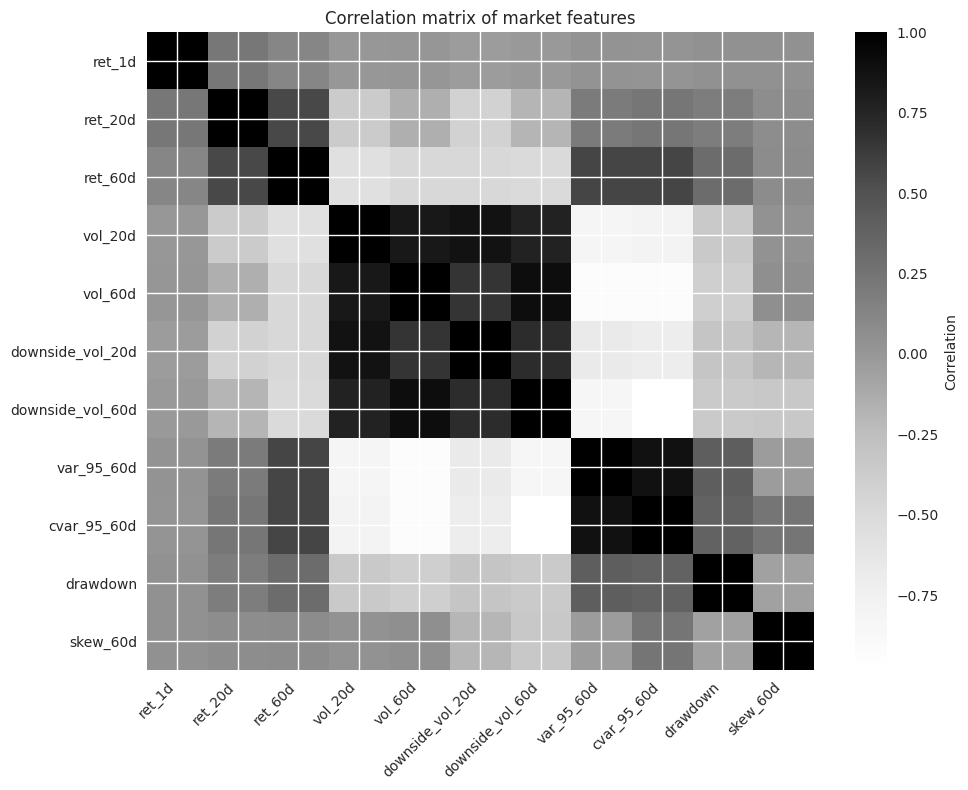

In [25]:
plt.figure(figsize=(10, 8))

im = plt.imshow(corr_matrix, aspect="auto")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlation matrix of market features")

cbar = plt.colorbar(im)
cbar.set_label("Correlation")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300)

plt.show()

The correlation matrix confirms that volatility, downside risk and tail-risk measures are strongly related, while return-based variables capture a different dimension of market behaviour.

### 13. Daily returns

The figure displays the daily log returns of the IBEX 35 over the sample period.

These features provide initial evidence of the relevance of modeling market risk using measures that explicitly account for time variation and extreme events.

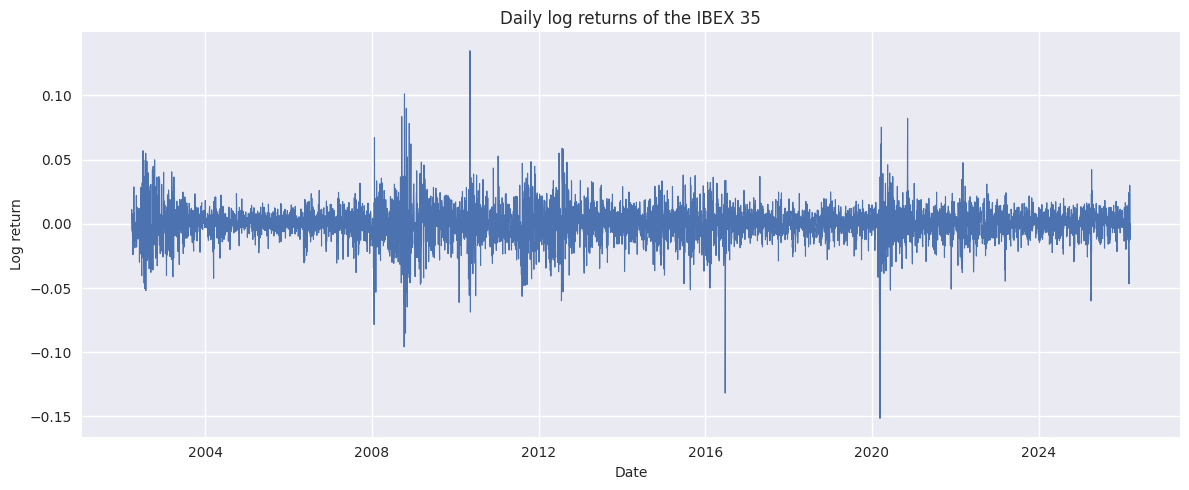

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["ret_1d"], linewidth=0.8)

plt.title("Daily log returns of the IBEX 35")
plt.xlabel("Date")
plt.ylabel("Log return")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "daily_returns_ibex35.png", dpi=300)

plt.show()

### 13.2 Volatility dynamics

The figure shows the evolution of rolling market volatility over a 60-day window.

Volatility exhibits clear time variation, with prolonged periods of low risk alternating with sharp spikes associated with market stress episodes. These spikes tend to cluster in time, reinforcing the evidence of volatility clustering observed in the return series.

This behaviour supports the idea that market risk is not constant over time and motivates the use of dynamic risk measures in subsequent analysis.

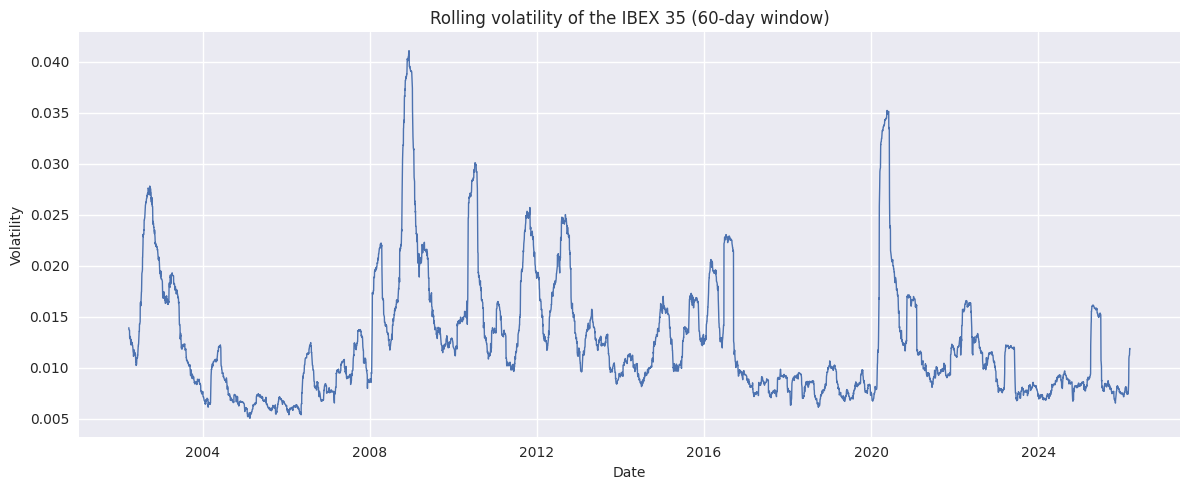

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["vol_60d"], linewidth=1)

plt.title("Rolling volatility of the IBEX 35 (60-day window)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "volatility_60d.png", dpi=300)

plt.show()

### 13.3 Volatility and downside risk

Figure X compares total rolling volatility with downside volatility over a 60-day window.

The two series move closely together, but downside volatility becomes especially relevant during stress episodes, when negative returns account for a larger share of total market variability. This suggests that periods of elevated risk are not simply characterized by greater dispersion, but by a more intense concentration of adverse movements.

This distinction is important because it reinforces the idea that market stress is asymmetric and that negative returns contribute disproportionately to the overall risk environment.

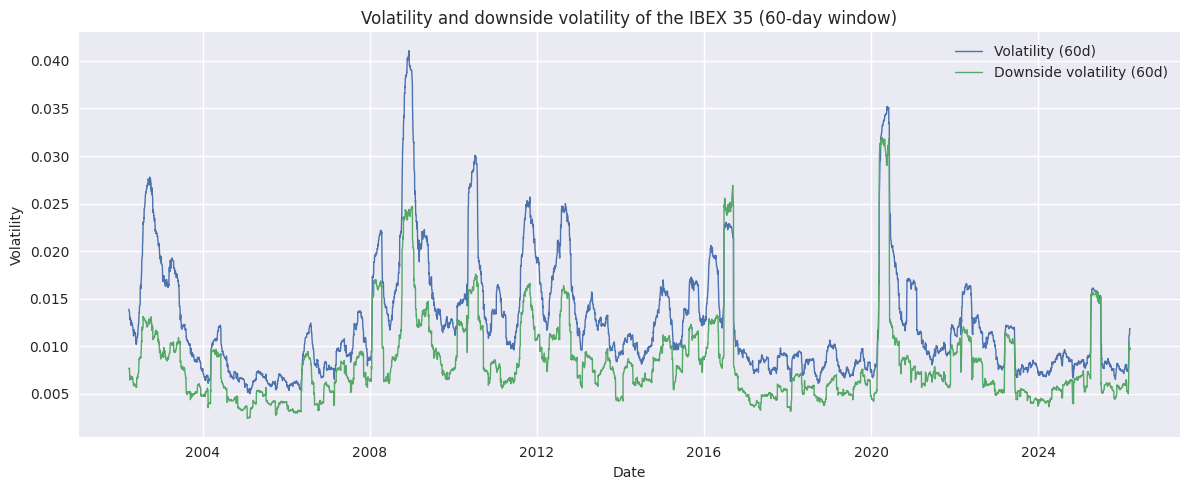

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["vol_60d"], label="Volatility (60d)", linewidth=1)
plt.plot(master_df["date"], master_df["downside_vol_60d"], label="Downside volatility (60d)", linewidth=1)

plt.title("Volatility and downside volatility of the IBEX 35 (60-day window)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "volatility_vs_downside_60d.png", dpi=300)

plt.show()

### 13.4 Market drawdown

Figure X shows the evolution of market drawdowns over time.

Drawdowns capture the cumulative losses from previous peaks and therefore reflect sustained periods of market deterioration rather than isolated daily shocks. Large and persistent drawdowns are associated with crisis episodes, during which the market remains significantly below its historical maximum for extended periods.

This measure complements volatility and tail-risk indicators by introducing a cumulative perspective on market stress, highlighting the depth and duration of adverse market conditions.

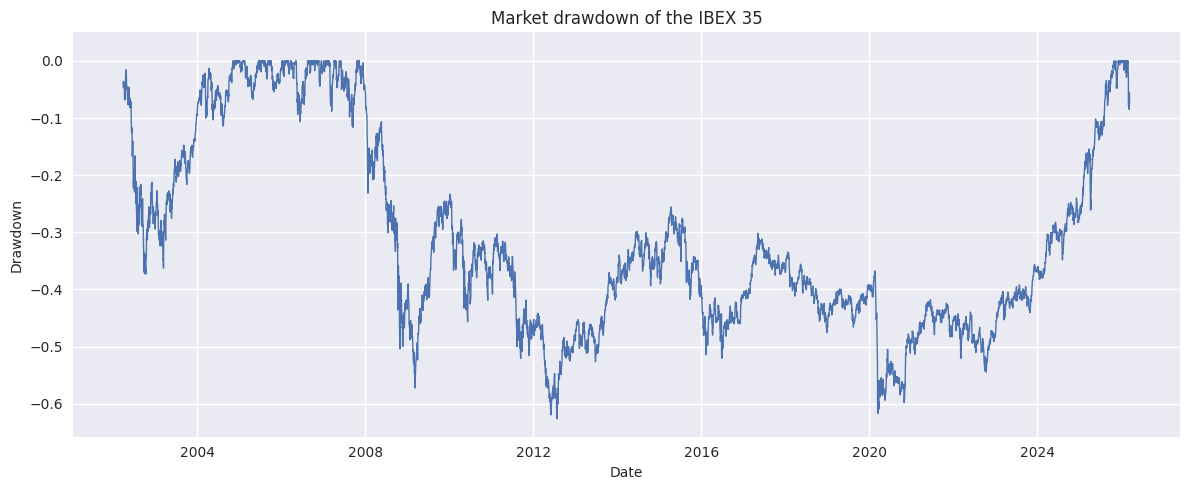

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["drawdown"], linewidth=1)

plt.title("Market drawdown of the IBEX 35")
plt.xlabel("Date")
plt.ylabel("Drawdown")

# add upper margin so the series is not stuck to the top boundary
plt.ylim(master_df["drawdown"].min()*1.05, 0.05)

plt.tight_layout()

plt.savefig(FIGURES_DIR / "drawdown_ibex35.png", dpi=300)

plt.show()

### 13.5 Tail risk: VaR and CVaR

Figure X presents the evolution of Value at Risk (VaR) and Conditional Value at Risk (CVaR) at the 95% confidence level using a 60-day rolling window.

Both measures capture the dynamics of extreme negative returns, but CVaR provides additional information by reflecting the average loss beyond the VaR threshold. As a result, CVaR is consistently more negative than VaR and becomes especially pronounced during periods of market stress.

The joint analysis of these two indicators highlights that not only the frequency of extreme events increases during turbulent periods, but also their severity, reinforcing the relevance of tail-risk measures in financial risk analysis.

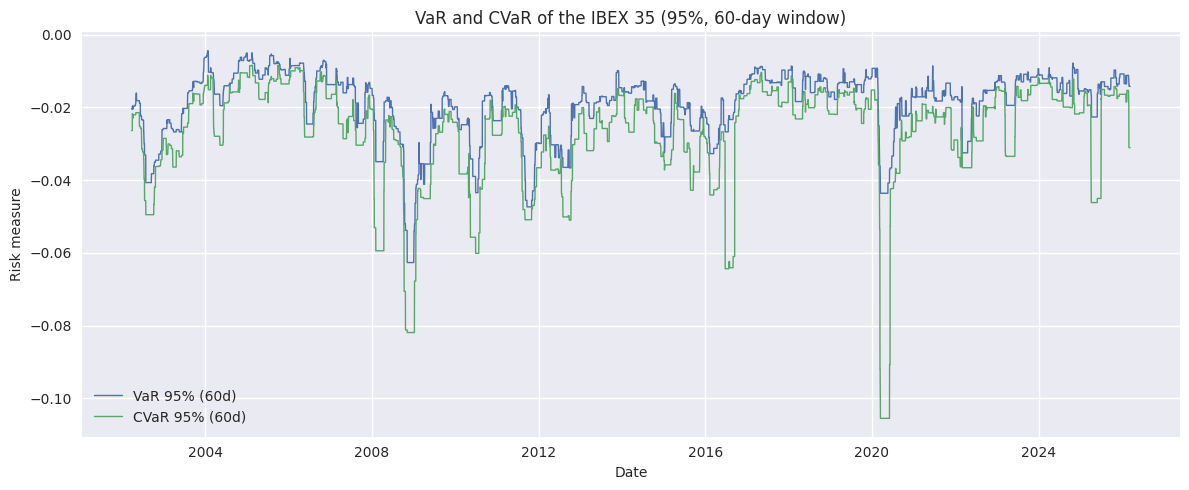

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["var_95_60d"], label="VaR 95% (60d)", linewidth=1)
plt.plot(master_df["date"], master_df["cvar_95_60d"], label="CVaR 95% (60d)", linewidth=1)

plt.title("VaR and CVaR of the IBEX 35 (95%, 60-day window)")
plt.xlabel("Date")
plt.ylabel("Risk measure")
plt.legend()

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "var_cvar_60d.png", dpi=300)

plt.show()

### 13.6 Distribution of returns

Figure X shows the distribution of daily log returns of the IBEX 35.

The distribution exhibits clear deviations from normality, with a pronounced peak around the mean and heavy tails. These features indicate that extreme returns occur more frequently than would be expected under a Gaussian framework.

In addition, the distribution tends to display slight negative skewness, reflecting a higher probability of large negative returns compared to positive ones. This asymmetry reinforces the relevance of downside and tail-risk measures in the analysis of financial markets.

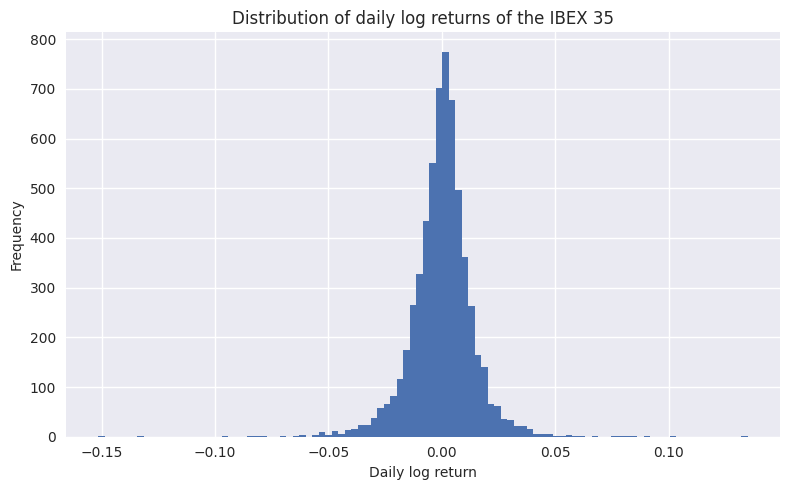

In [41]:
plt.figure(figsize=(8, 5))

plt.hist(master_df["ret_1d"], bins=100)

plt.title("Distribution of daily log returns of the IBEX 35")
plt.xlabel("Daily log return")
plt.ylabel("Frequency")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "returns_distribution.png", dpi=300)

plt.show()

The distribution of daily returns exhibits clear deviations from normality. In particular, the presence of fat tails and extreme observations highlights the relevance of tail-risk measures such as VaR and CVaR.

This reinforces the idea that risk in financial markets is not fully captured by standard deviation alone, especially during periods of market stress.

Overall, the descriptive analysis reveals key stylized facts of financial returns, including volatility clustering, heavy tails and asymmetry. These features suggest that market risk evolves over time in a non-linear and regime-dependent manner.

This motivates the use of more advanced modelling approaches capable of capturing changes in the underlying market conditions, which are introduced in the following chapter.